In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

In [2]:
train = pd.read_csv('train.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Number of outliers=  69
Skew:  LotArea    12.207688
dtype: float64


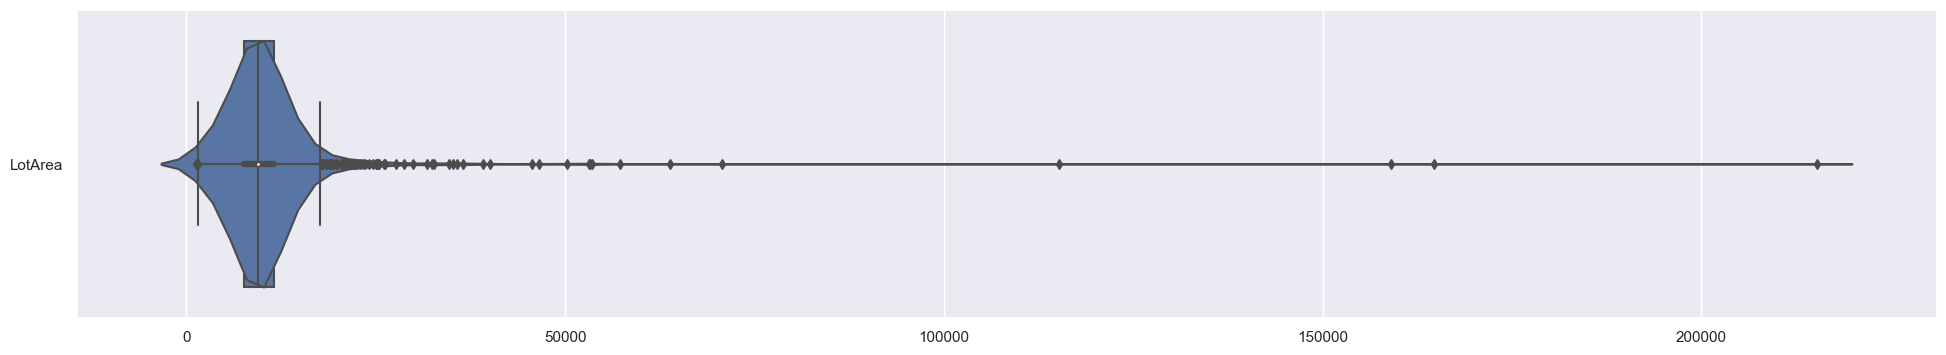

In [3]:
lotarea = pd.DataFrame(train['LotArea'])
f = plt.figure(figsize=(24, 4))
sb.boxplot(data = lotarea, orient = "h")
sb.violinplot(data = lotarea, orient = "h")
Q1 = lotarea['LotArea'].quantile(0.25) 
Q3 = lotarea['LotArea'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = lotarea[(lotarea['LotArea'] < lower_bound) | (lotarea['LotArea'] > upper_bound)]
num_outliers = len(outliers)
print("Number of outliers= ", num_outliers)
print("Skew: ", lotarea.skew())

Number of outliers =  31
Skew:  GrLivArea    1.36656
dtype: float64


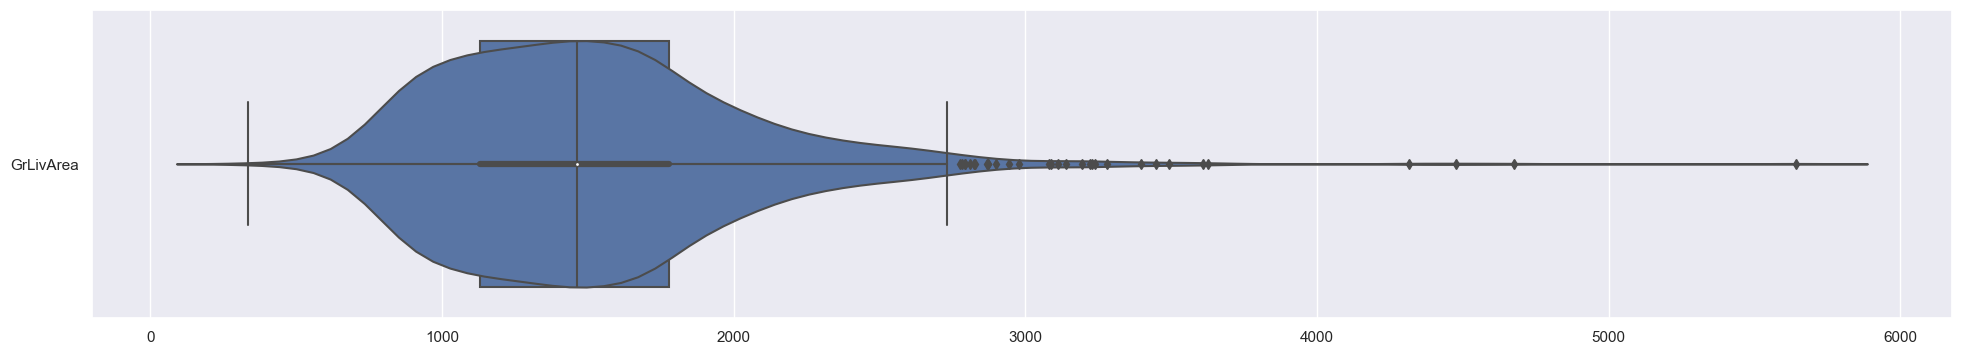

In [4]:
grlivarea = pd.DataFrame(train['GrLivArea'])
f = plt.figure(figsize=(24, 4))
sb.boxplot(data = grlivarea, orient = "h")
sb.violinplot(data = grlivarea, orient = "h")
Q1 = grlivarea['GrLivArea'].quantile(0.25) 
Q3 = grlivarea['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = grlivarea[(grlivarea['GrLivArea'] < lower_bound) | (grlivarea['GrLivArea'] > upper_bound)]
num_outliers = len(outliers)
print("Number of outliers = ", num_outliers)
print("Skew: ", grlivarea.skew())


Number of outliers =  61
Skew:  TotalBsmtSF    1.524255
dtype: float64


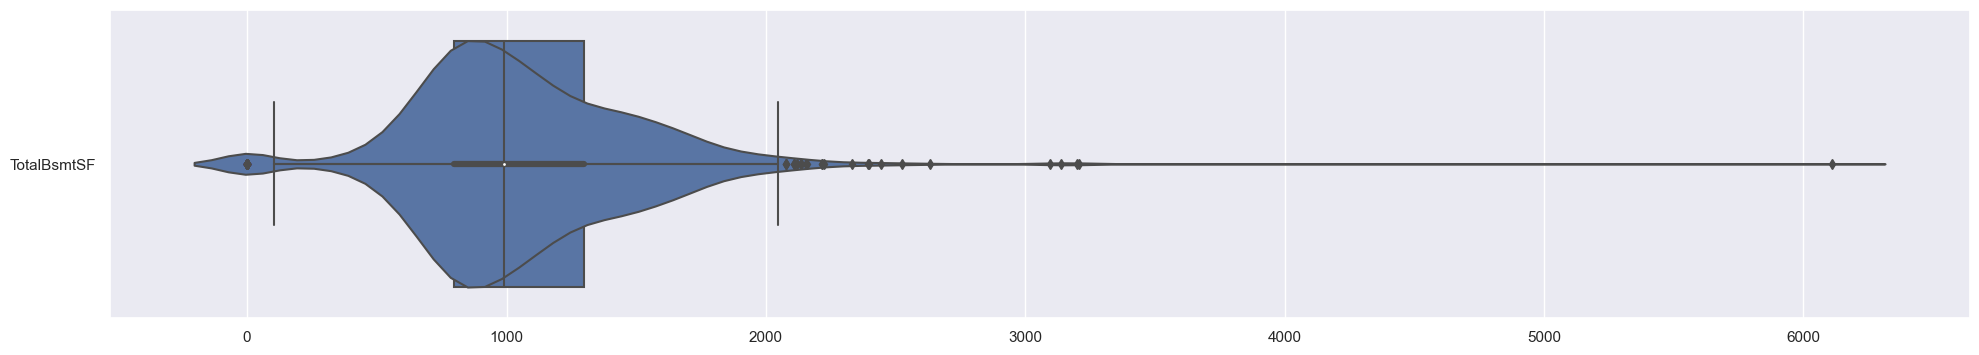

In [5]:
totalbsmtsf = pd.DataFrame(train['TotalBsmtSF'])
f = plt.figure(figsize=(24, 4))
sb.boxplot(data = totalbsmtsf, orient = "h")
sb.violinplot(data = totalbsmtsf, orient = "h")
Q1 = totalbsmtsf['TotalBsmtSF'].quantile(0.25) 
Q3 = totalbsmtsf['TotalBsmtSF'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = totalbsmtsf[(totalbsmtsf['TotalBsmtSF'] < lower_bound) | (totalbsmtsf['TotalBsmtSF'] > upper_bound)]
num_outliers = len(outliers)
print("Number of outliers = ", num_outliers)
print("Skew: ", totalbsmtsf.skew())

Number of outliers =  21
Skew:  GarageArea    0.179981
dtype: float64


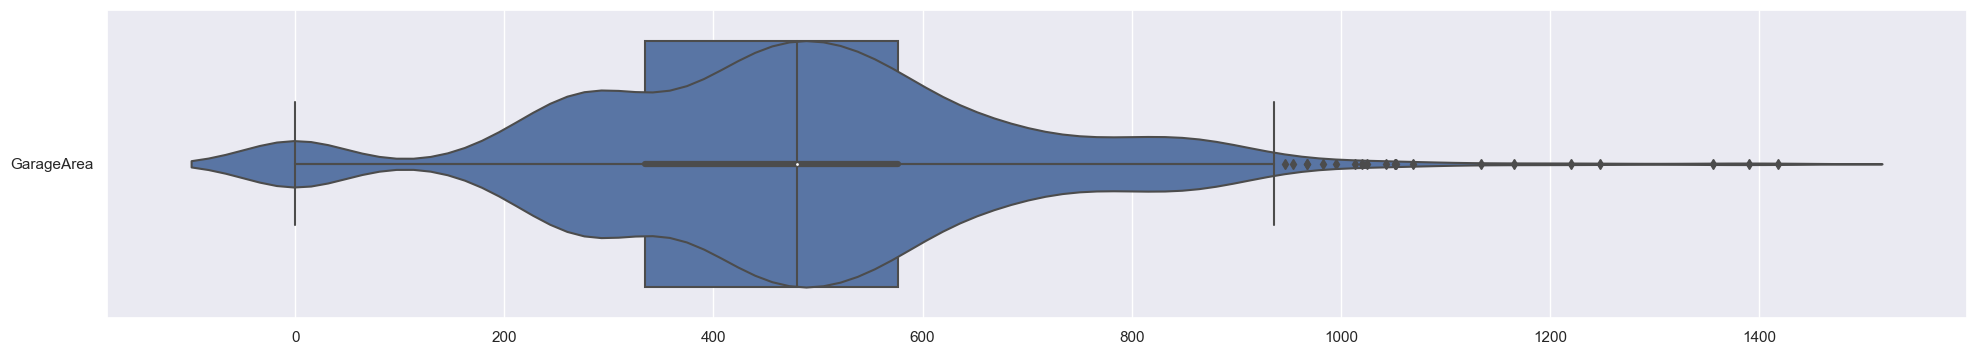

In [6]:
garagearea = pd.DataFrame(train['GarageArea'])
f = plt.figure(figsize=(24, 4))
sb.boxplot(data = garagearea, orient = "h")
sb.violinplot(data = garagearea, orient = "h")
Q1 = garagearea['GarageArea'].quantile(0.25)
Q3 = garagearea['GarageArea'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = garagearea[(garagearea['GarageArea'] < lower_bound) | (garagearea['GarageArea'] > upper_bound)]
num_outliers = len(outliers)
print("Number of outliers = ", num_outliers)
print("Skew: ", garagearea.skew())

In [7]:
numDF = pd.DataFrame(train[["LotArea", "GrLivArea", "TotalBsmtSF", "GarageArea", "SalePrice"]])
numDF.corr()

,LotArea,GrLivArea,TotalBsmtSF,GarageArea,SalePrice
LotArea,1.000000,0.263116,0.260833,0.180403,0.263843
GrLivArea,0.263116,1.000000,0.454868,0.468997,0.708624
TotalBsmtSF,0.260833,0.454868,1.000000,0.486665,0.613581
GarageArea,0.180403,0.468997,0.486665,1.000000,0.623431
SalePrice,0.263843,0.708624,0.613581,0.623431,1.000000


**1.
a) Lot Area, 69 outliers
b) Lot Area, positive skew
c) GrLivArea, GarageArea. Correlation values with SalePrice for both variables are the highest and closest to the value 1.**

In [8]:
mssubclass = pd.DataFrame(train["MSSubClass"])
print(mssubclass.value_counts(), "\n")

neighborhood = pd.DataFrame(train["Neighborhood"])
print(neighborhood.value_counts(), "\n")

bldgtype = pd.DataFrame(train["BldgType"])
print(bldgtype.value_counts(), "\n")

overallqual = pd.DataFrame(train["OverallQual"])
print(overallqual.value_counts(), "\n")

MSSubClass
20            536
60            299
50            144
120            87
30             69
160            63
70             60
80             58
90             52
190            30
85             20
75             16
45             12
180            10
40              4
Name: count, dtype: int64 

Neighborhood
NAmes           225
CollgCr         150
OldTown         113
Edwards         100
Somerst          86
Gilbert          79
NridgHt          77
Sawyer           74
NWAmes           73
SawyerW          59
BrkSide          58
Crawfor          51
Mitchel          49
NoRidge          41
Timber           38
IDOTRR           37
ClearCr          28
StoneBr          25
SWISU            25
Blmngtn          17
MeadowV          17
BrDale           16
Veenker          11
NPkVill           9
Blueste           2
Name: count, dtype: int64 

BldgType
1Fam        1220
TwnhsE       114
Duplex        52
Twnhs         43
2fmCon        31
Name: count, dtype: int64 

OverallQual
5              3

**2.a) Neighborhood, NAmes = 225**

<Axes: xlabel='MSSubClass', ylabel='SalePrice'>

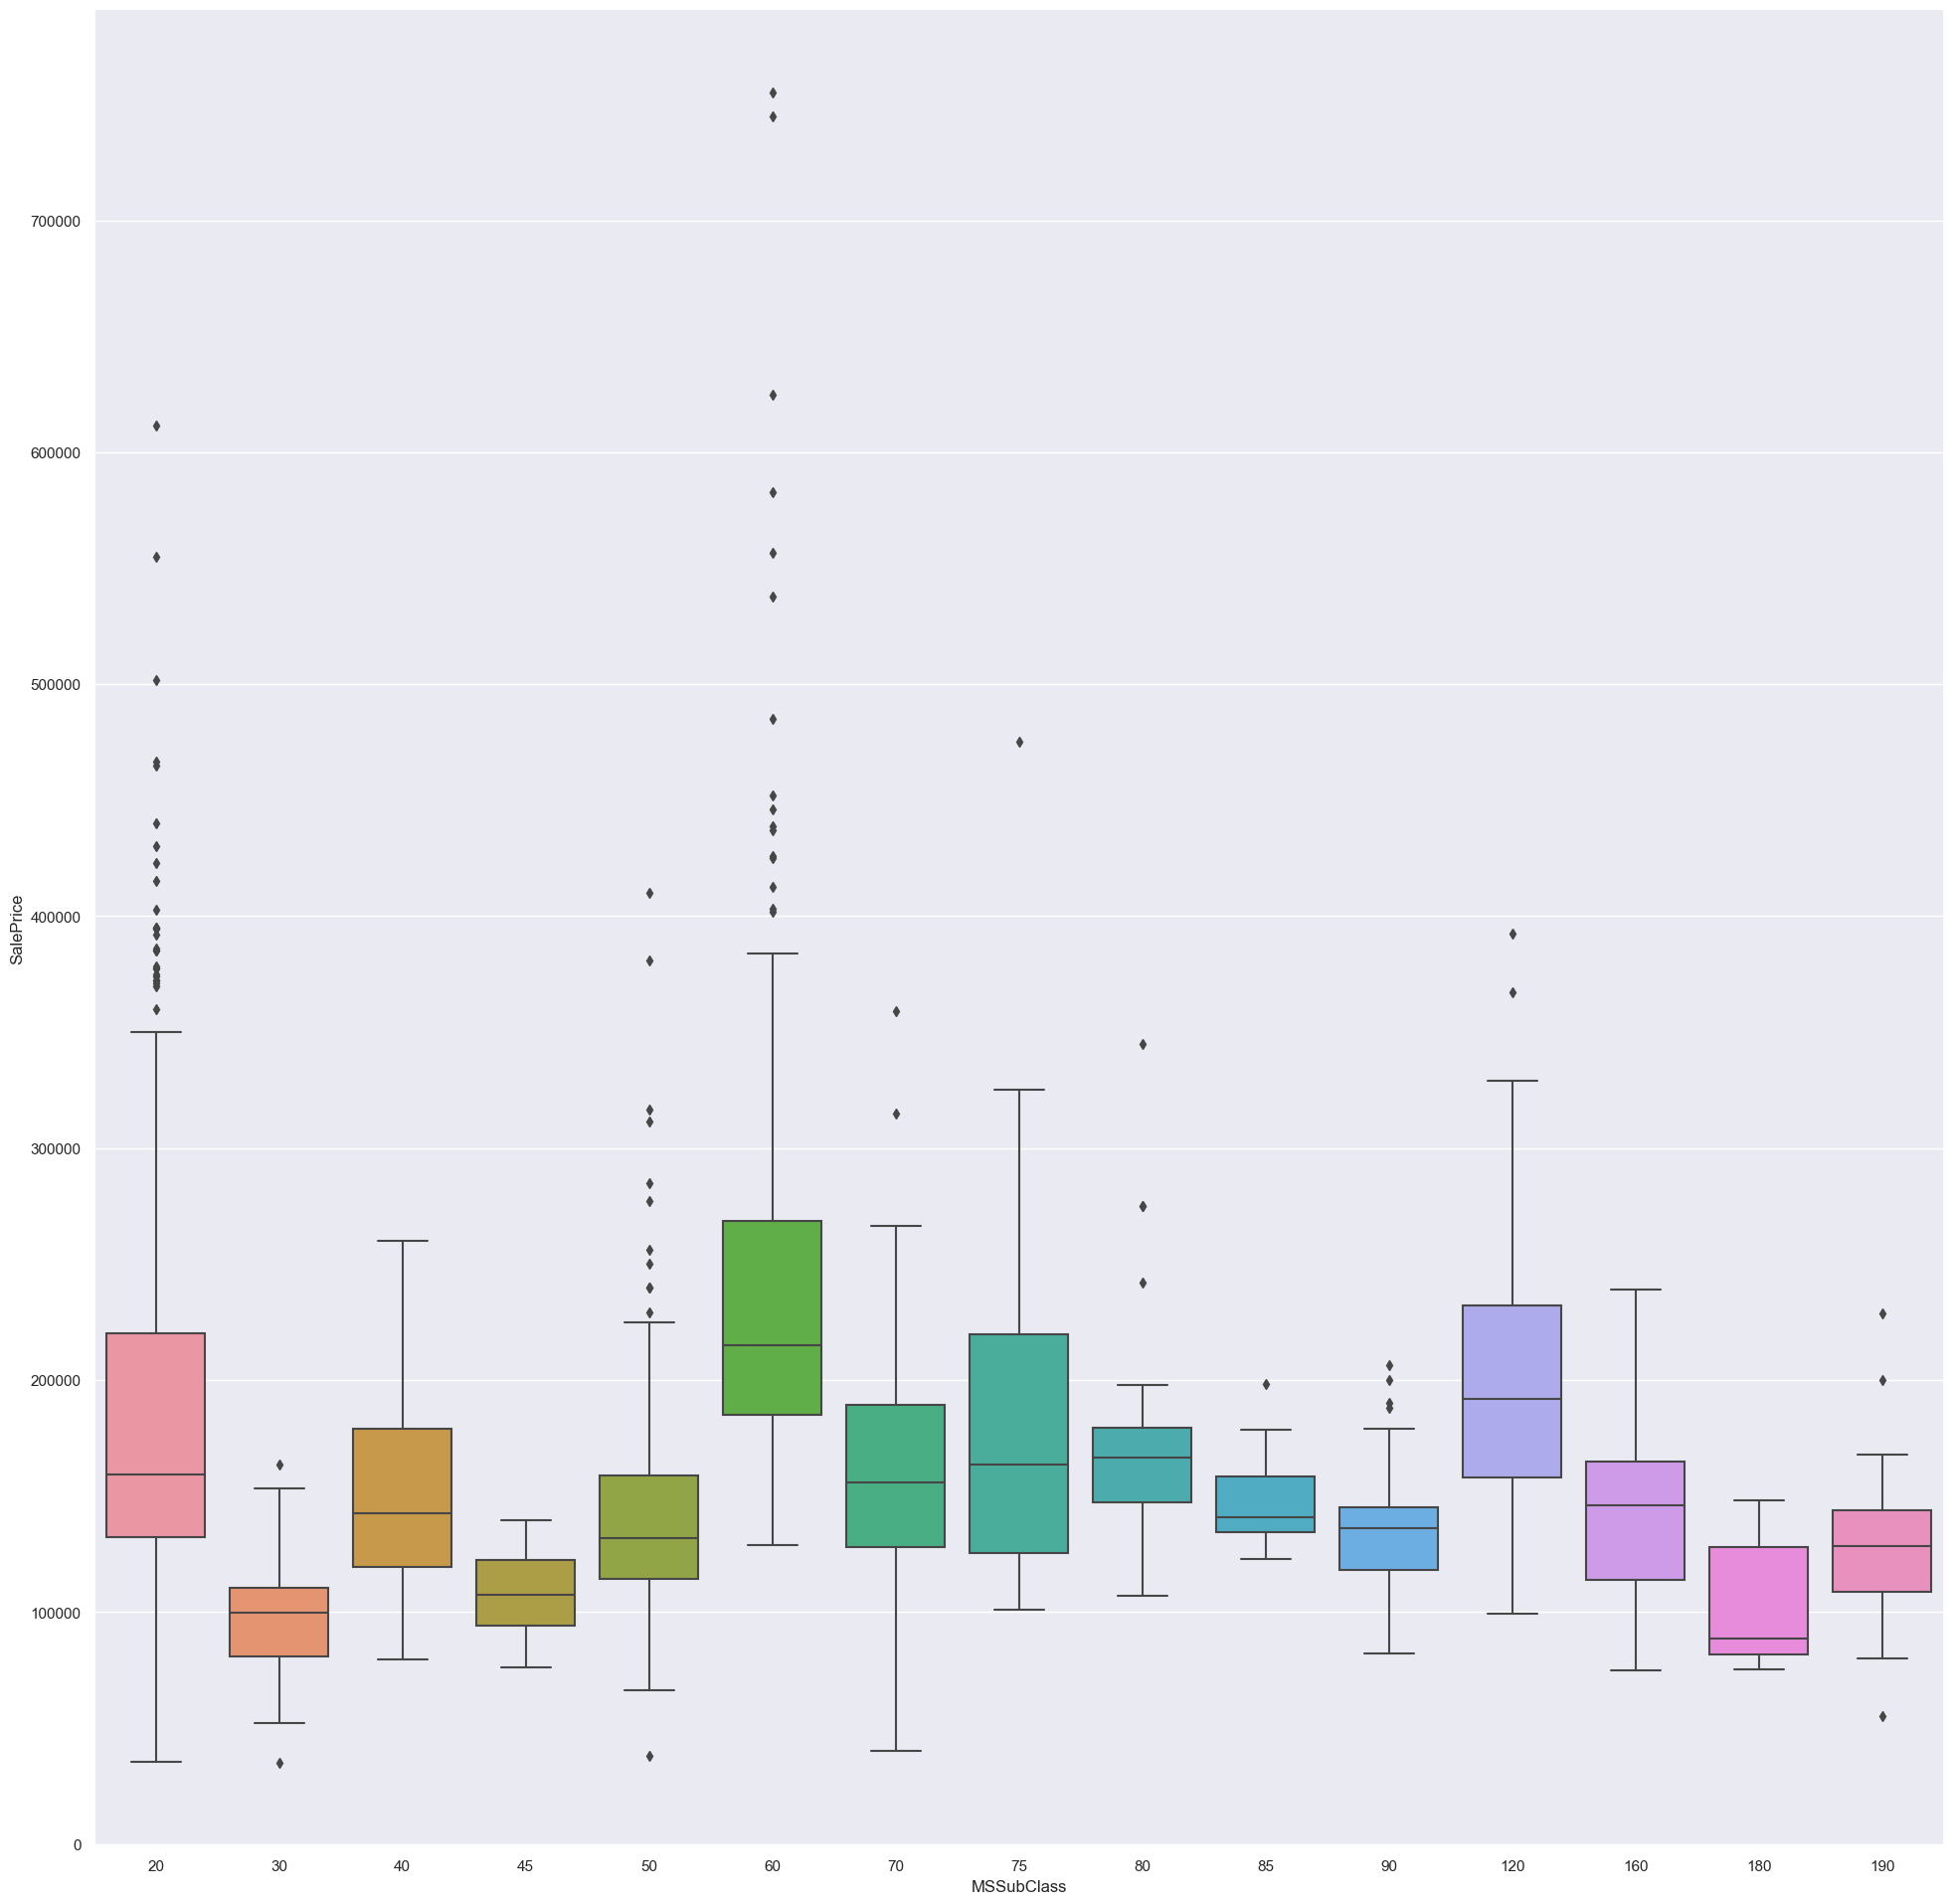

In [9]:
f = plt.figure(figsize=(24, 24))
sb.boxplot(data = train, x = 'MSSubClass', y = 'SalePrice')

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

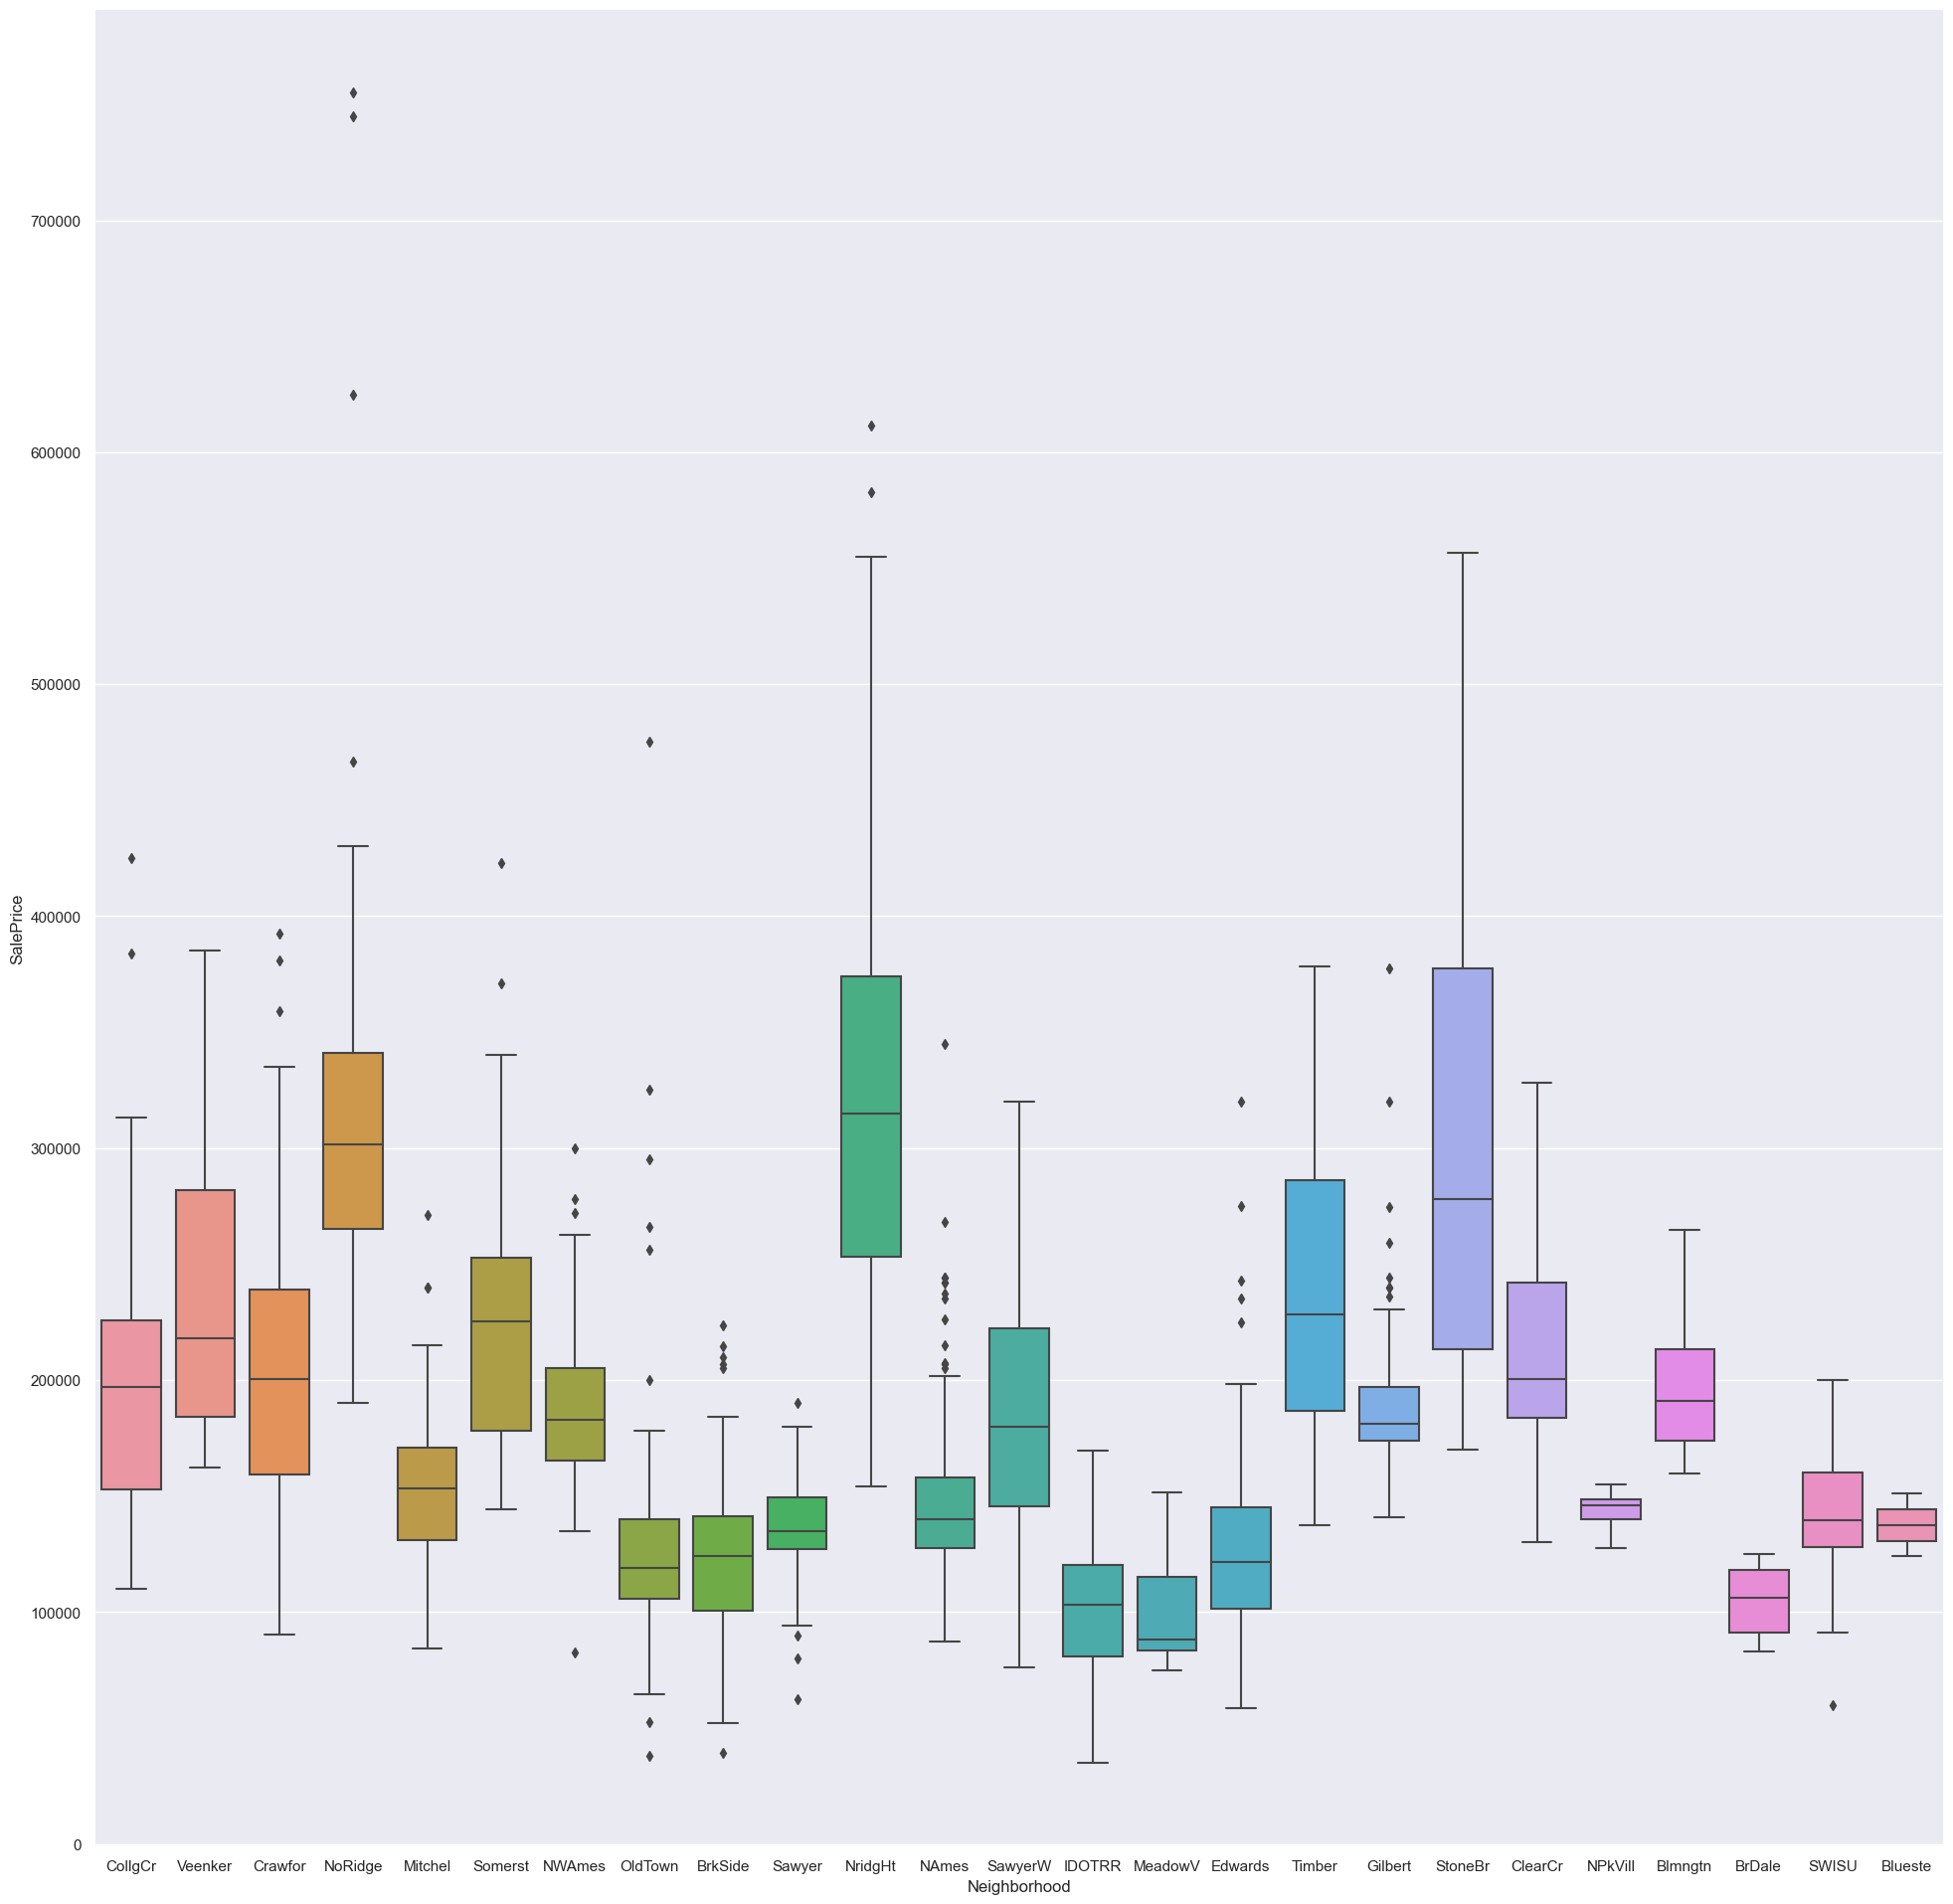

In [10]:
f = plt.figure(figsize=(24, 24))
sb.boxplot(data = train, x = 'Neighborhood', y = 'SalePrice')

<Axes: xlabel='BldgType', ylabel='SalePrice'>

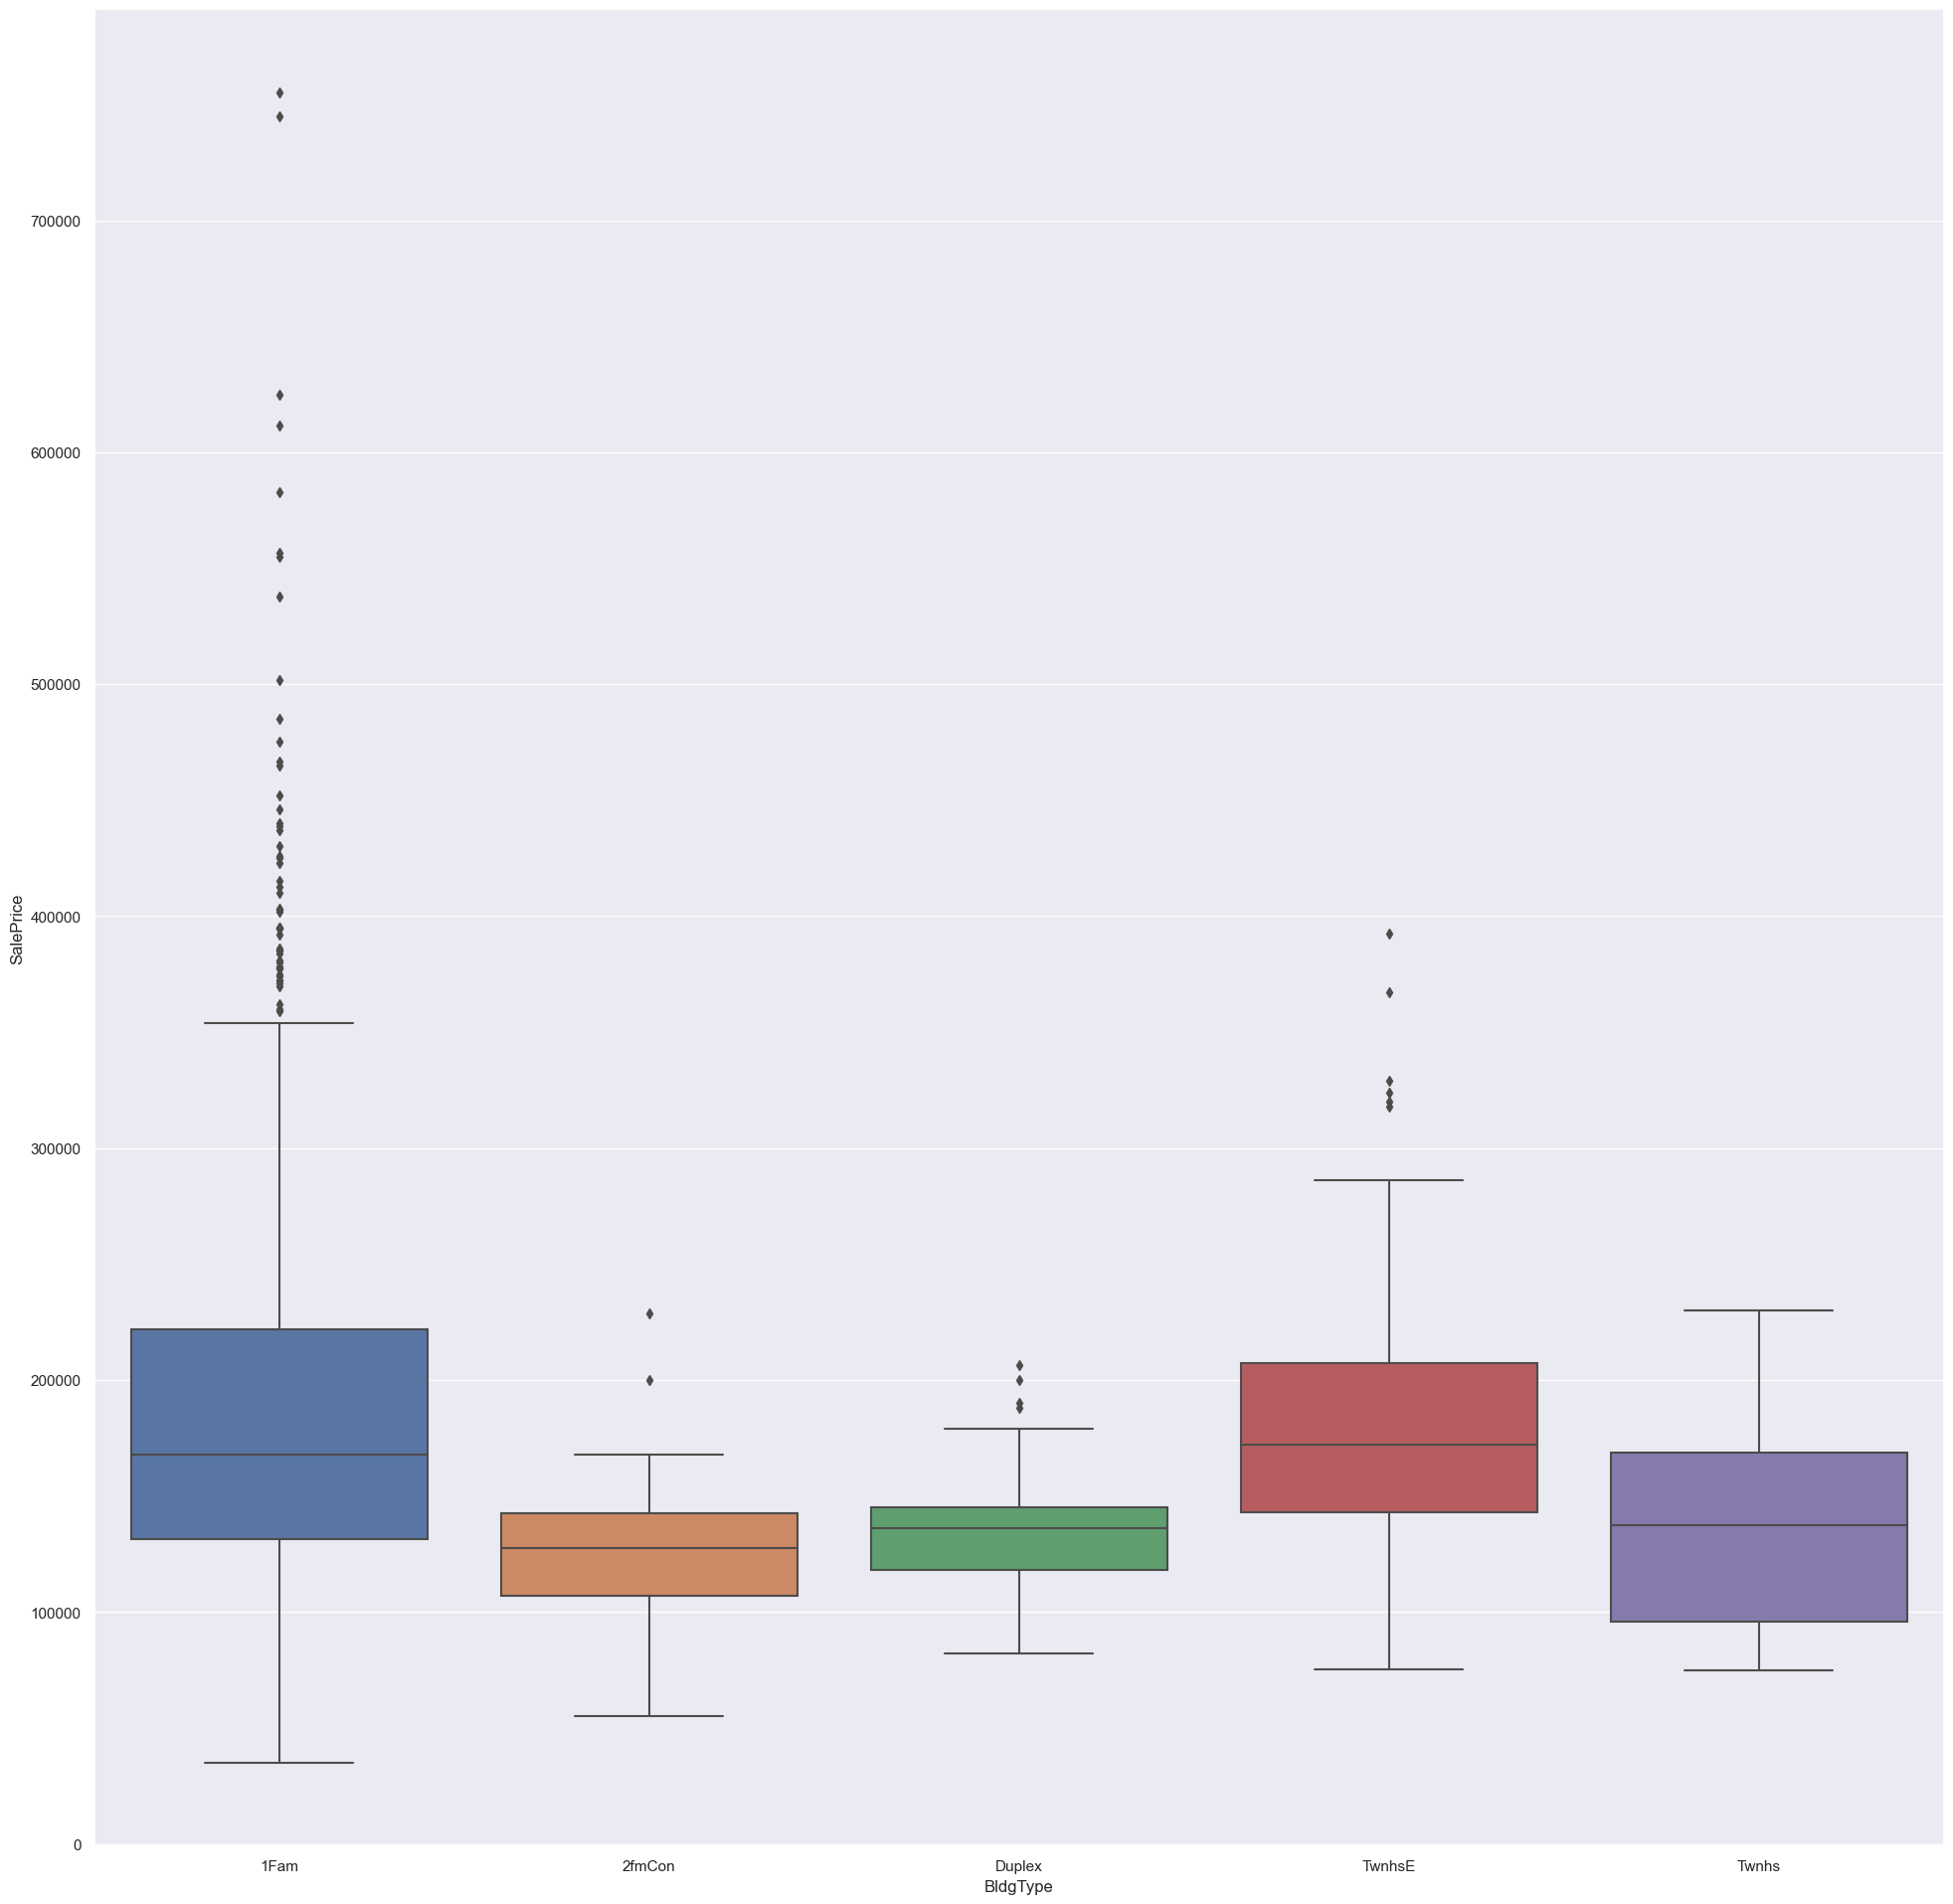

In [11]:
f = plt.figure(figsize=(24, 24))
sb.boxplot(data = train, x = 'BldgType', y = 'SalePrice')

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

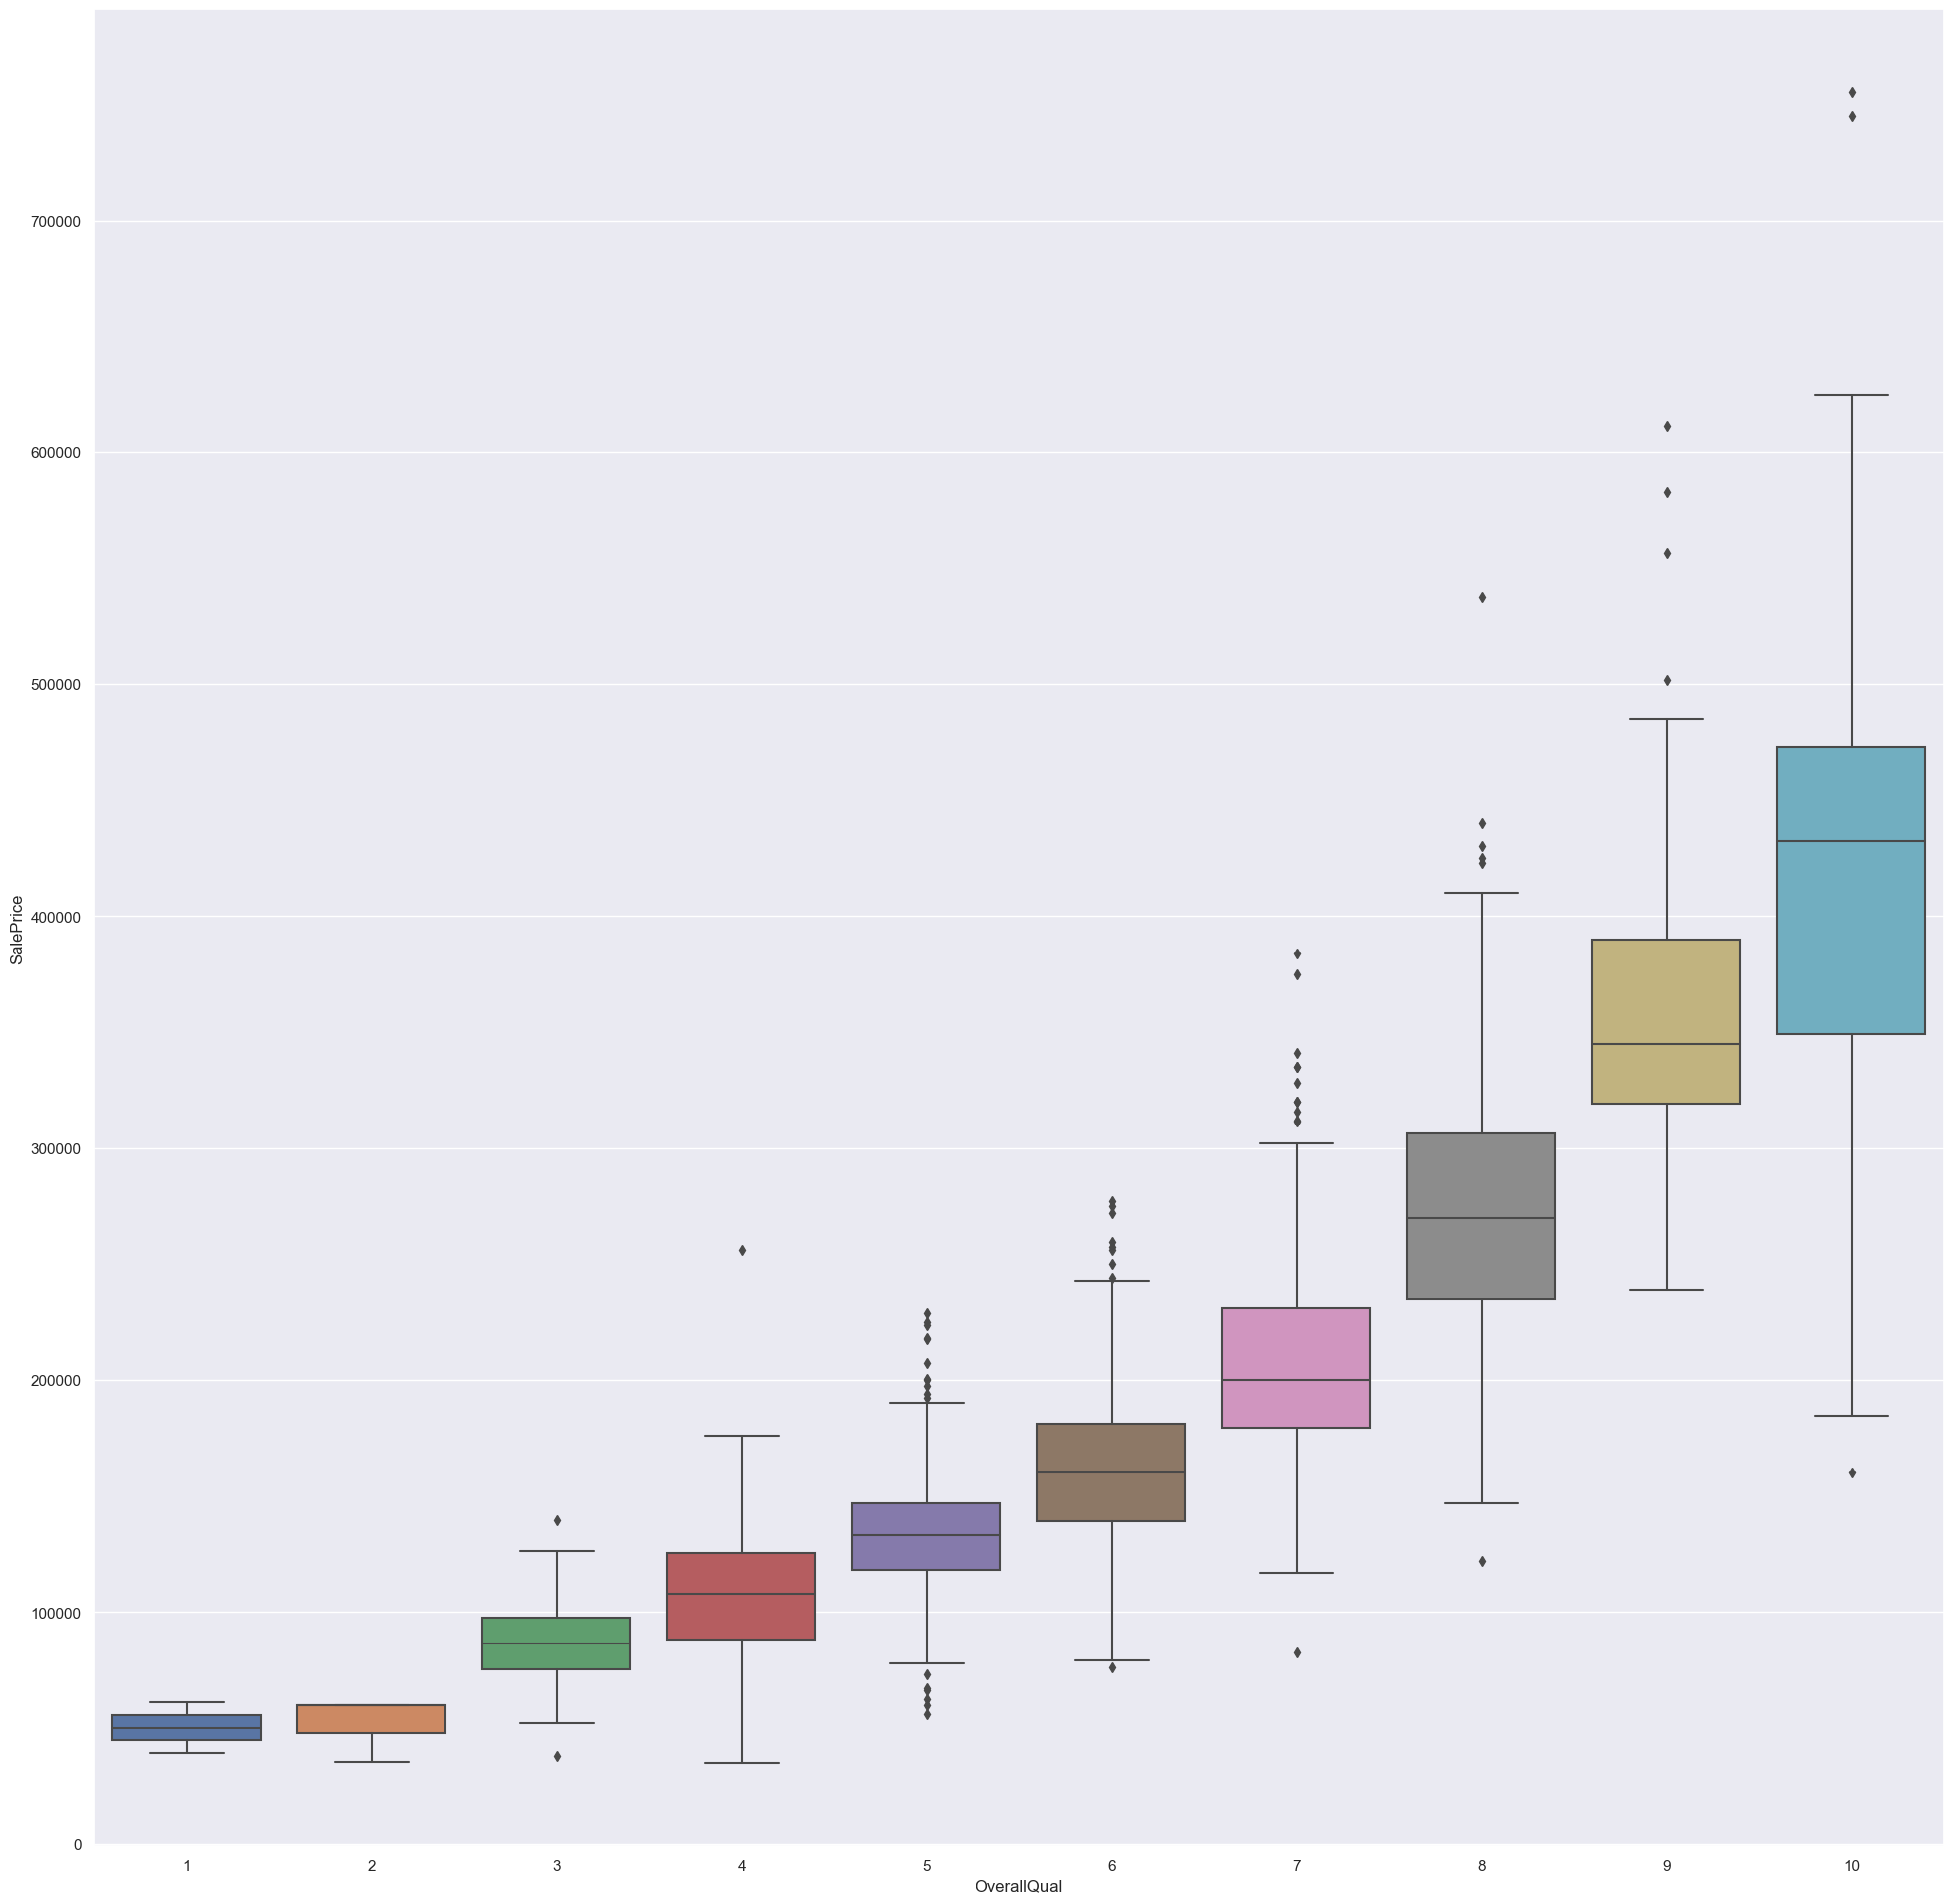

In [12]:
f = plt.figure(figsize=(24, 24))
sb.boxplot(data = train, x = 'OverallQual', y = 'SalePrice')

**2.b) OverallQual and Neighborhood.
OverallQual - Clear increasing trend in SalePrice with respect to an increase in OverallQual.
Neighborhood - There is a significant difference in the Sale price of certain nieghborhoods.
MSSubClass, BldgType- Sale prices remain relatively constant in different categorical values. As MSSubClass increases, no clear trend in SalePrice can be observed as well.**

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

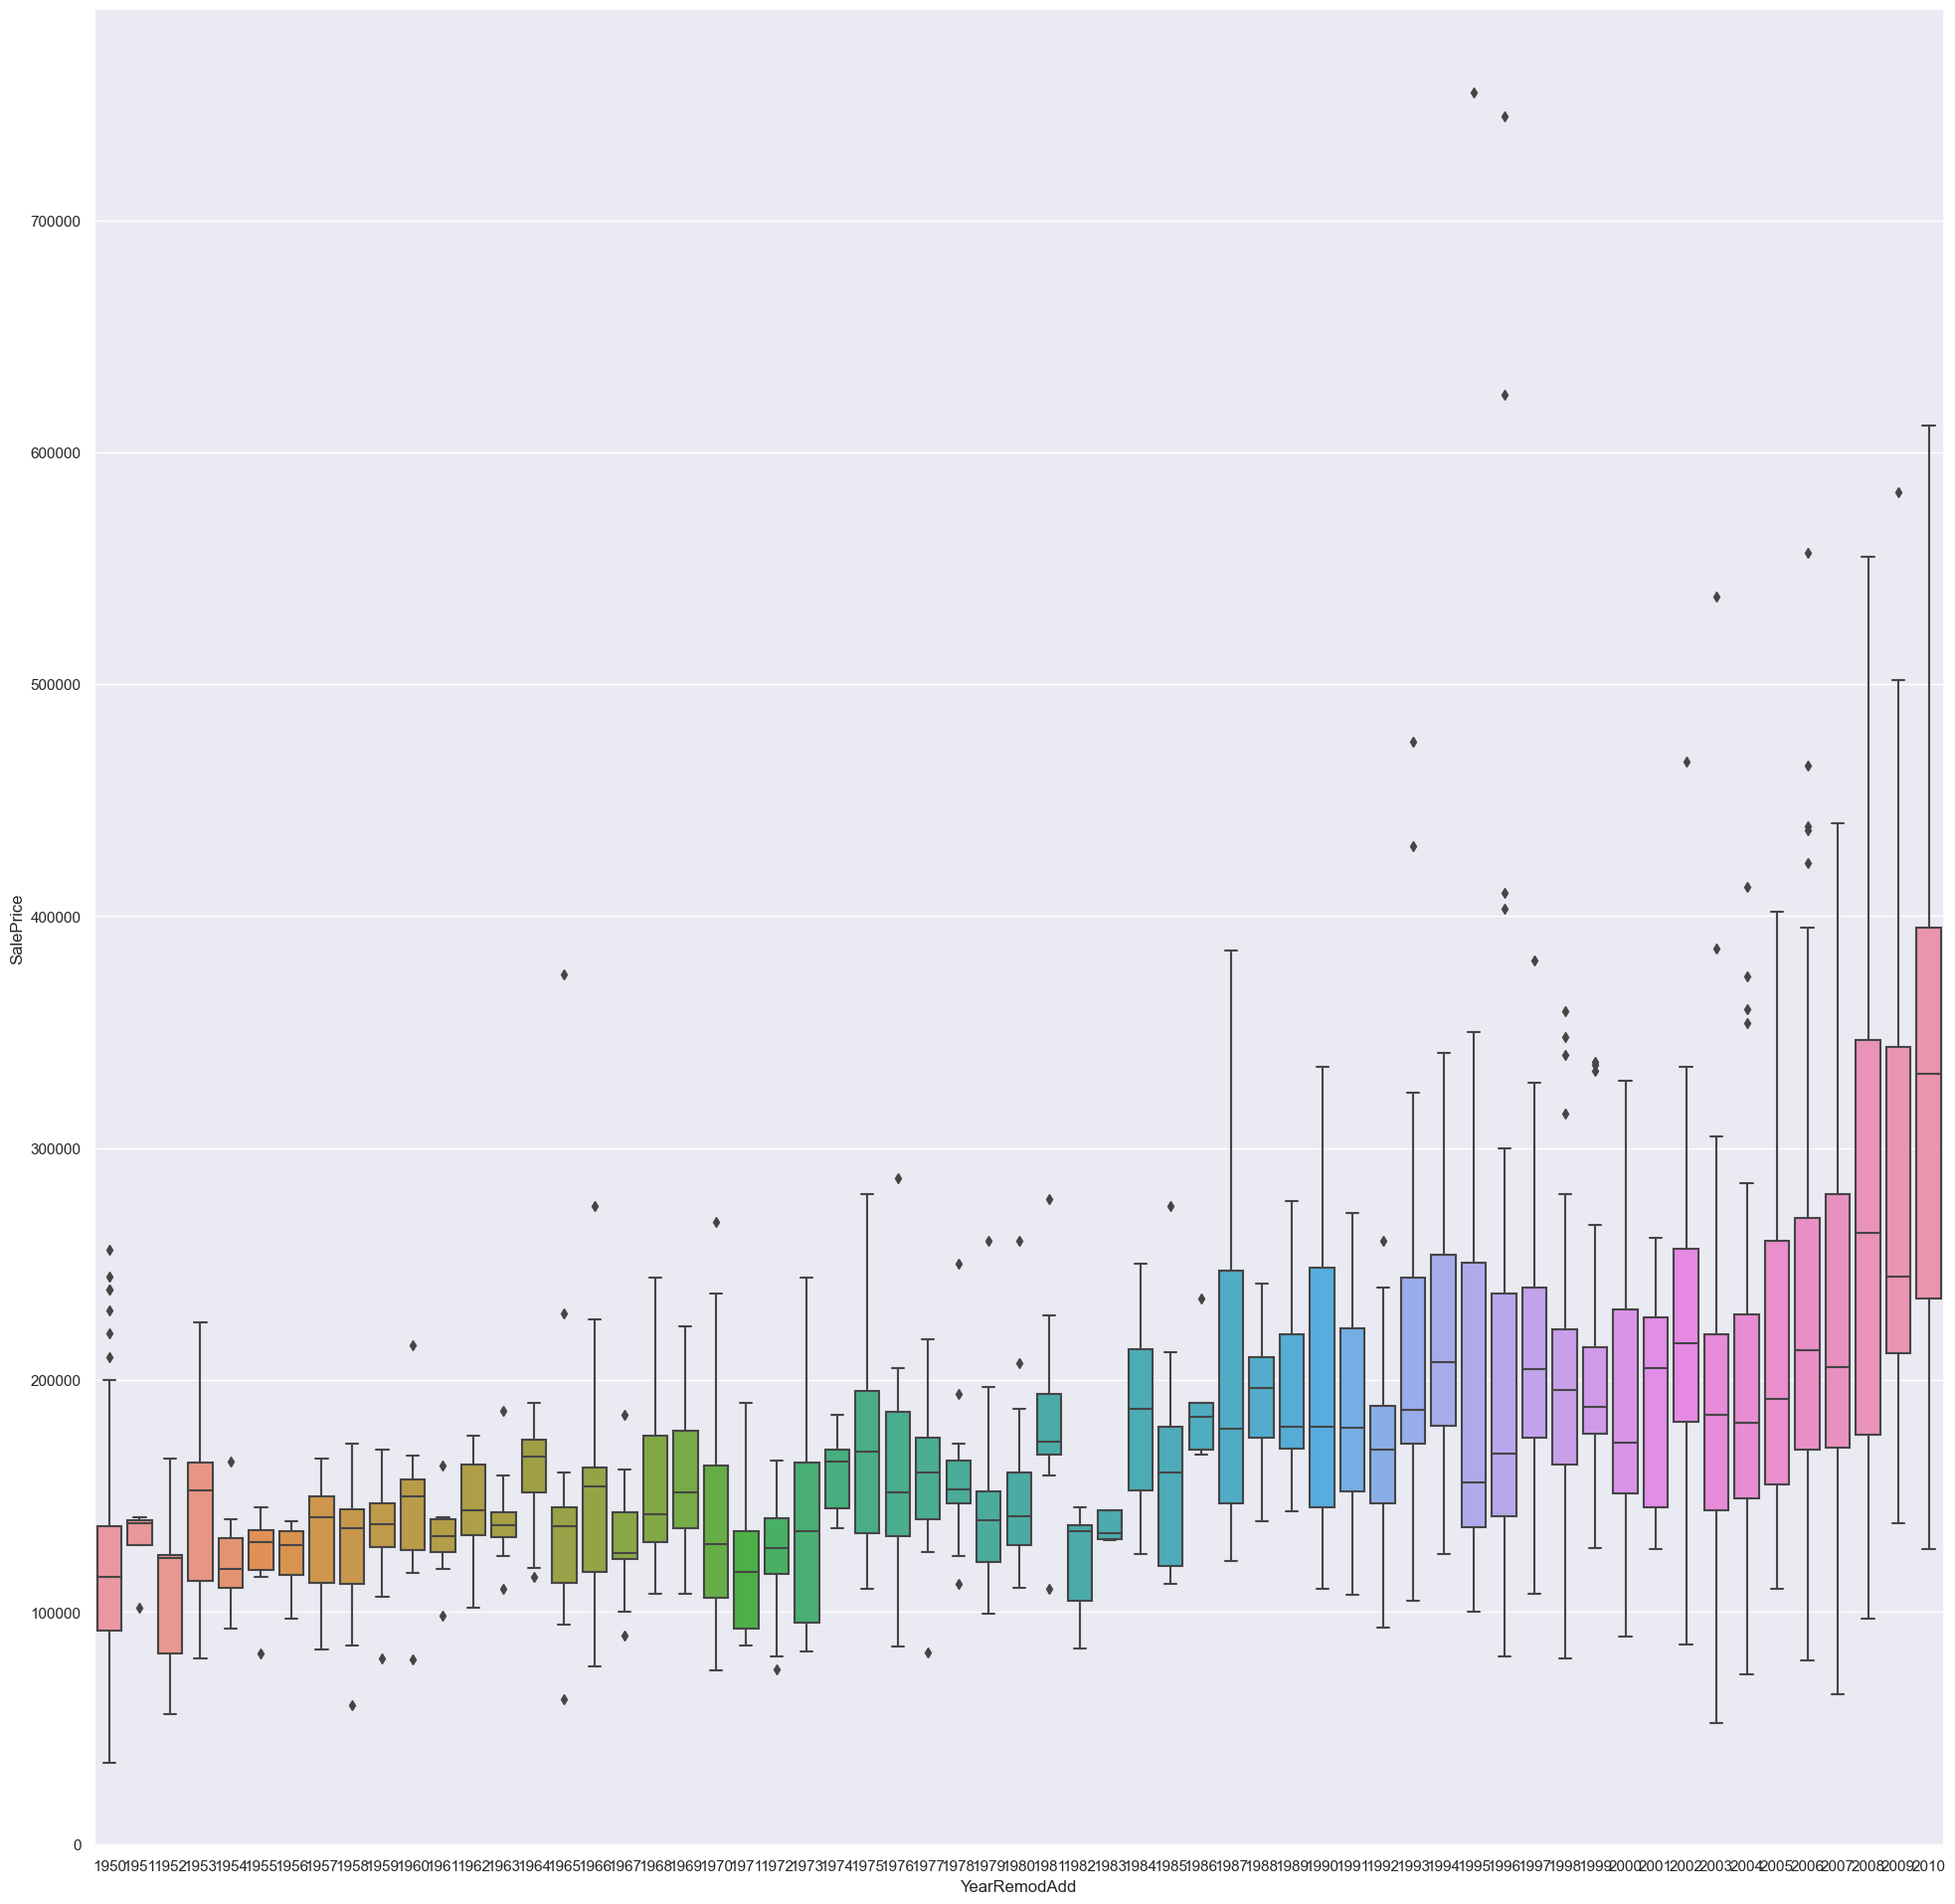

In [13]:
yearremodadd = pd.DataFrame(train['YearRemodAdd'])
f = plt.figure(figsize=(24, 24))
sb.boxplot(data = train, x = 'YearRemodAdd', y = 'SalePrice')

**3.b) Yes. Based on the boxplot, as the year of remodel increases, an increase in SalePrice can be observed.**